In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bank-full.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 45211
Number of columns: 17


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [10]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate records percentage:", round(duplicate_percentage, 2), "%")

Duplicate records percentage: 0.0 %


In [11]:
unknown_counts = {}
for column in df.select_dtypes(include='object').columns:
    count = (df[column] == 'unknown').sum()
    if count > 0:
        unknown_counts[column] = count

print("Unknown values by column:")
print(unknown_counts)

Unknown values by column:
{'job': np.int64(288), 'education': np.int64(1857), 'contact': np.int64(13020), 'poutcome': np.int64(36959)}


In [12]:
for column, count in unknown_counts.items():
    percentage = (count / len(df)) * 100
    print(column, ":", count, "(", round(percentage, 2), "%)")

job : 288 ( 0.64 %)
education : 1857 ( 4.11 %)
contact : 13020 ( 28.8 %)
poutcome : 36959 ( 81.75 %)


In [13]:
financial_variables = ['age', 'balance', 'campaign', 'previous', 'duration']

display(df[financial_variables].describe())

,age,balance,campaign,previous,duration
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,2.763841,0.580323,258.163080
std,10.618762,3044.765829,3.098021,2.303441,257.527812
min,18.000000,-8019.000000,1.000000,0.000000,0.000000
25%,33.000000,72.000000,1.000000,0.000000,103.000000
50%,39.000000,448.000000,2.000000,0.000000,180.000000
75%,48.000000,1428.000000,3.000000,0.000000,319.000000
max,95.000000,102127.000000,63.000000,275.000000,4918.000000


In [14]:
print("Lowest account balance:")
display(df.nsmallest(10, 'balance')[['age', 'job', 'balance', 'default', 'housing', 'loan', 'y']])

Lowest account balance:


,age,job,balance,default,housing,loan,y
12909,26,blue-collar,-8019,yes,no,yes,no
15682,49,management,-6847,yes,no,yes,no
38736,60,management,-4057,no,yes,no,no
7413,43,management,-3372,yes,yes,no,no
1896,57,self-employed,-3313,yes,yes,yes,no
32713,39,self-employed,-3058,no,yes,yes,yes
18573,40,technician,-2827,yes,yes,yes,no
31509,52,management,-2712,no,yes,yes,no
25119,49,blue-collar,-2604,yes,yes,no,no
14434,51,management,-2282,no,yes,yes,no


In [15]:
print("Account Balance Statistics")
print("--------------------------")

print("Average balance:", round(df['balance'].mean(), 2))
print("Median balance:", round(df['balance'].median(), 2))
print("Minimum balance:", df['balance'].min())
print("Maximum balance:", df['balance'].max())

Account Balance Statistics
--------------------------
Average balance: 1362.27
Median balance: 448.0
Minimum balance: -8019
Maximum balance: 102127


In [16]:
negative_balance = df[df['balance'] < 0]

print("Customers with negative balance:", len(negative_balance))
print("Percentage of customers with negative balance:",
      round(len(negative_balance) / len(df) * 100, 2), "%")

Customers with negative balance: 3766
Percentage of customers with negative balance: 8.33 %


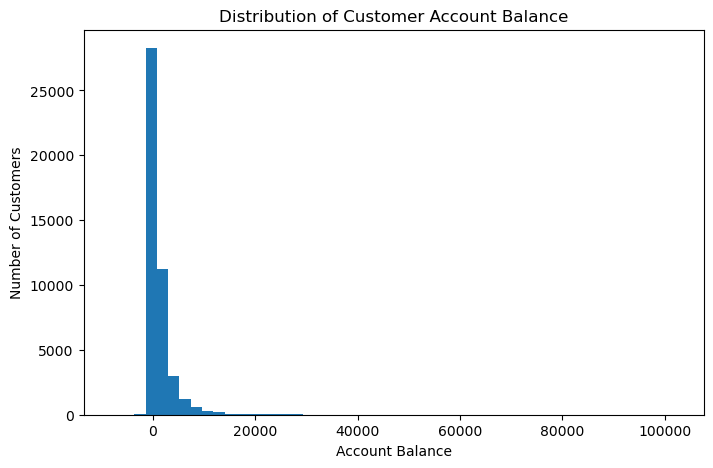

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df['balance'], bins=50)

plt.title("Distribution of Customer Account Balance")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
default_counts = df['default'].value_counts()

print("Default Status:")
print(default_counts)

print("\nPercentage:")
print(df['default'].value_counts(normalize=True) * 100)

Default Status:
default
no     44396
yes      815
Name: count, dtype: int64

Percentage:
default
no     98.197341
yes     1.802659
Name: proportion, dtype: float64


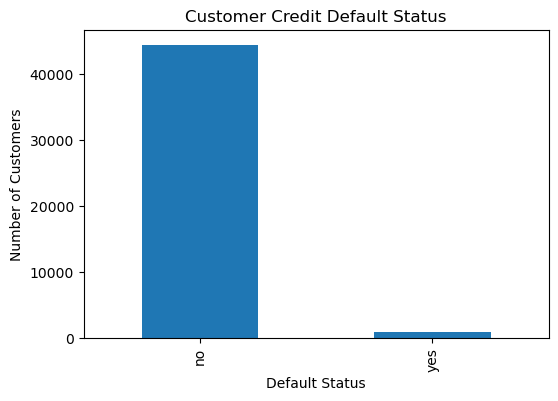

In [19]:
plt.figure(figsize=(6, 4))

df['default'].value_counts().plot(kind='bar')

plt.title("Customer Credit Default Status")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
print("Housing Loan:")
print(df['housing'].value_counts())

print("\nPersonal Loan:")
print(df['loan'].value_counts())

Housing Loan:
housing
yes    25130
no     20081
Name: count, dtype: int64

Personal Loan:
loan
no     37967
yes     7244
Name: count, dtype: int64


In [21]:
print("Housing Loan Percentage:")
print(df['housing'].value_counts(normalize=True) * 100)

print("\nPersonal Loan Percentage:")
print(df['loan'].value_counts(normalize=True) * 100)

Housing Loan Percentage:
housing
yes    55.583818
no     44.416182
Name: proportion, dtype: float64

Personal Loan Percentage:
loan
no     83.977351
yes    16.022649
Name: proportion, dtype: float64


In [22]:
housing_subscription = pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
) * 100

print("Subscription rate by housing loan status:")
display(housing_subscription)

Subscription rate by housing loan status:


y,no,yes
housing,,
no,83.297645,16.702355
yes,92.300040,7.699960


In [23]:
personal_subscription = pd.crosstab(
    df['loan'],
    df['y'],
    normalize='index'
) * 100

print("Subscription rate by personal loan status:")
display(personal_subscription)

Subscription rate by personal loan status:


y,no,yes
loan,,
no,87.344273,12.655727
yes,93.318609,6.681391


In [24]:
print("Campaign Contact Statistics")
print("---------------------------")

print("Average contacts:", round(df['campaign'].mean(), 2))
print("Median contacts:", df['campaign'].median())
print("Maximum contacts:", df['campaign'].max())

Campaign Contact Statistics
---------------------------
Average contacts: 2.76
Median contacts: 2.0
Maximum contacts: 63


In [25]:
repeated_contacts = df[df['campaign'] > 5]

print("Customers contacted more than 5 times:",
      len(repeated_contacts))

print("Percentage:",
      round(len(repeated_contacts) / len(df) * 100, 2), "%")

Customers contacted more than 5 times: 4355
Percentage: 9.63 %


In [26]:
campaign_subscription = pd.crosstab(
    df['campaign'],
    df['y'],
    normalize='index'
) * 100

display(campaign_subscription.head(15))

y,no,yes
campaign,,
1,85.402417,14.597583
2,88.796481,11.203519
3,88.806376,11.193624
4,90.999432,9.000568
5,92.120181,7.879819
6,92.873741,7.126259
7,93.605442,6.394558
8,94.074074,5.925926
9,93.577982,6.422018


In [27]:
df['campaign_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 3, 5, 10, float('inf')],
    labels=[
        '1 contact',
        '2-3 contacts',
        '4-5 contacts',
        '6-10 contacts',
        'More than 10 contacts'
    ]
)

campaign_group_rate = pd.crosstab(
    df['campaign_group'],
    df['y'],
    normalize='index'
) * 100

display(campaign_group_rate)

y,no,yes
campaign_group,,
1 contact,85.402417,14.597583
2-3 contacts,88.799512,11.200488
4-5 contacts,91.373439,8.626561
6-10 contacts,93.478949,6.521051
More than 10 contacts,96.070234,3.929766


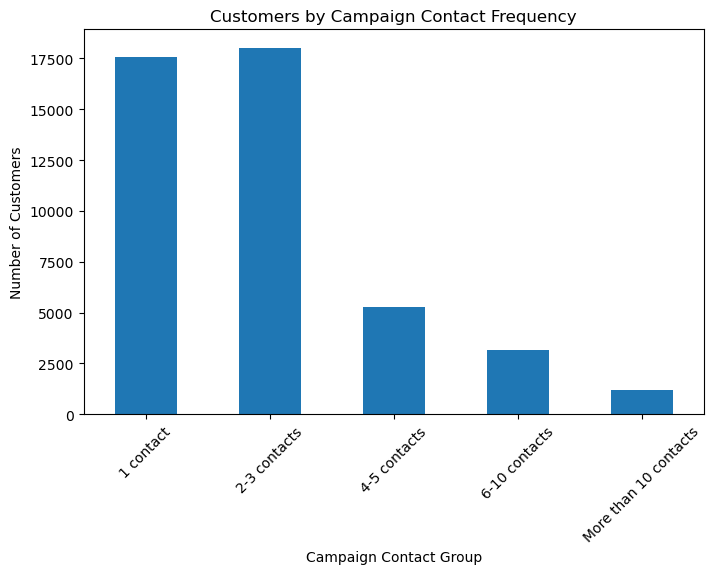

In [28]:
plt.figure(figsize=(8, 5))

df['campaign_group'].value_counts().sort_index().plot(kind='bar')

plt.title("Customers by Campaign Contact Frequency")
plt.xlabel("Campaign Contact Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

In [29]:
print("Previous contact statistics:")
print(df['previous'].describe())

print("\nCustomers contacted previously:",
      (df['previous'] > 0).sum())

print("Percentage contacted previously:",
      round((df['previous'] > 0).mean() * 100, 2), "%")

Previous contact statistics:
count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

Customers contacted previously: 8257
Percentage contacted previously: 18.26 %


In [30]:
subscription_counts = df['y'].value_counts()

print("Subscription Outcome:")
print(subscription_counts)

print("\nSubscription Percentage:")
print(
    df['y'].value_counts(normalize=True).mul(100).round(2)
)

Subscription Outcome:
y
no     39922
yes     5289
Name: count, dtype: int64

Subscription Percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


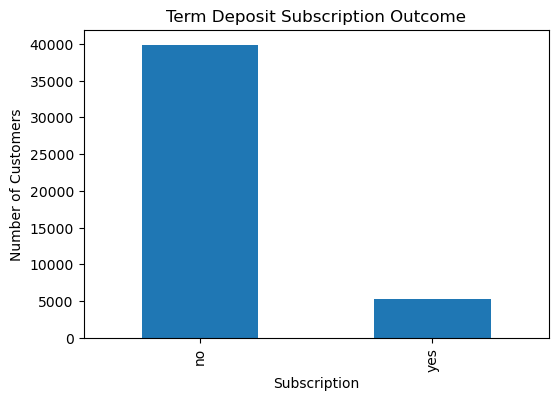

In [31]:
plt.figure(figsize=(6, 4))

df['y'].value_counts().plot(kind='bar')

plt.title("Term Deposit Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
subscription_rate = (df['y'] == 'yes').mean() * 100

print("Overall Subscription Rate:",
      round(subscription_rate, 2), "%")

Overall Subscription Rate: 11.7 %


In [33]:
class_counts = df['y'].value_counts()

majority_class = class_counts.max()
minority_class = class_counts.min()

imbalance_ratio = majority_class / minority_class

print("Majority class:", majority_class)
print("Minority class:", minority_class)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class: 39922
Minority class: 5289
Imbalance ratio: 7.55


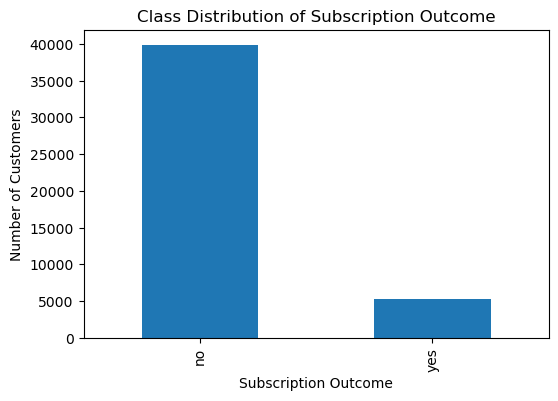

In [34]:
plt.figure(figsize=(6, 4))

df['y'].value_counts().plot(kind='bar')

plt.title("Class Distribution of Subscription Outcome")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.show()

In [35]:
duration_by_outcome = df.groupby('y')['duration'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

display(duration_by_outcome)

,count,mean,median,min,max
y,,,,,
no,39922,221.182806,164.0,0,4918
yes,5289,537.294574,426.0,8,3881


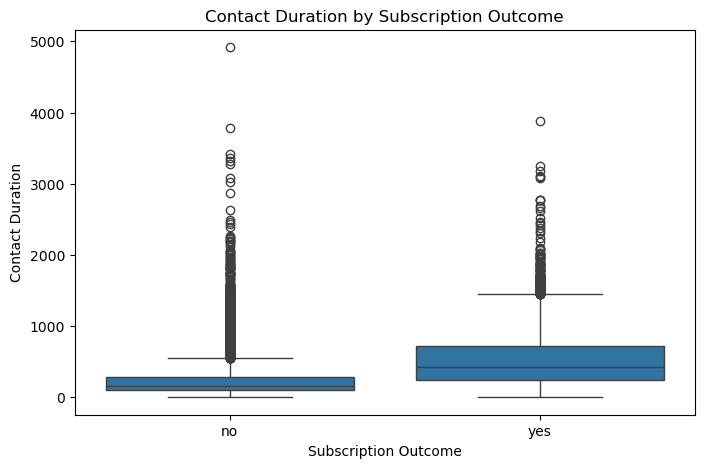

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='y', y='duration')

plt.title("Contact Duration by Subscription Outcome")
plt.xlabel("Subscription Outcome")
plt.ylabel("Contact Duration")

plt.show()

In [37]:
print("Dataset contains", len(df), "customer records.")

print("\nMonth distribution:")
print(df['month'].value_counts())

Dataset contains 45211 customer records.

Month distribution:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


### Risk 7: Limited Historical Data Risk

The dataset contains customer-level bank marketing observations and campaign-month information, but it is not a long-term continuous financial time series. Therefore, long-term trends, yearly seasonality and future financial behaviour cannot be reliably established from this dataset alone. Additional historical data would be required for stronger long-term forecasting.

### Risk 8: Privacy and Responsible Data Use

The dataset contains customer-related demographic and financial information. Such information should be handled responsibly and securely. Access should be restricted to authorized users, unnecessary personally identifiable information should not be exposed, and customer-level information should only be used for legitimate analytical purposes

| No. | Risk                                       |
| --- | ------------------------------------------ |
| 1   | Data Quality Risk                          |
| 2   | Financial Exposure Risk                    |
| 3   | Campaign Over-Contact Risk                 |
| 4   | Low Subscription / Conversion Risk         |
| 5   | Class Imbalance Risk                       |
| 6   | Information Leakage / Decision-Timing Risk |
| 7   | Limited Historical Data Risk               |
| 8   | Privacy and Responsible Data Use Risk      |


# Risk Assessment Matrix

| Risk | Likelihood | Impact | Risk Level |
|---|---|---|---|
| Data Quality Risk | Medium | High | High |
| Financial Exposure Risk | Medium | High | High |
| Campaign Over-Contact Risk | Medium | Medium | Medium |
| Low Subscription / Conversion Risk | High | High | High |
| Class Imbalance Risk | High | Medium | High |
| Information Leakage / Decision-Timing Risk | Medium | High | High |
| Limited Historical Data Risk | High | Medium | High |
| Privacy and Responsible Data Use Risk | Low | High | Medium |

# Risk Mitigation Strategies

### 1. Data Quality Risk
Perform duplicate checks, missing-value checks, unknown-value checks and outlier analysis before using the dataset.

### 2. Financial Exposure Risk
Use balance, default, housing loan and personal loan variables carefully and avoid making unsupported individual-level financial conclusions.

### 3. Campaign Over-Contact Risk
Monitor the number of contacts per customer and establish reasonable contact-frequency limits.

### 4. Low Subscription / Conversion Risk
Use customer segmentation and targeted campaigns to improve campaign efficiency and reduce unnecessary contacts.

### 5. Class Imbalance Risk
Use precision, recall, F1-score, ROC-AUC and confusion matrices instead of relying only on accuracy.

### 6. Information Leakage / Decision-Timing Risk
Separate variables that are available before customer contact from variables that become available only after the interaction.

### 7. Limited Historical Data Risk
Use longer historical datasets when performing long-term forecasting and avoid treating this campaign dataset as a complete financial time series.

### 8. Privacy and Responsible Data Use Risk
Protect customer information, restrict access to authorized users and follow applicable privacy and organizational data-handling policies.

# Conclusion

The risk analysis identified several business, financial, data and modelling risks in the Bank Marketing dataset. The major risks include low subscription conversion, financial exposure, data-quality issues, class imbalance, repeated customer contact, information leakage, limited historical information and responsible data-use concerns.

The analysis shows that these risks can affect the reliability of business decisions if they are not properly considered. Appropriate mitigation strategies include improving data quality, monitoring campaign frequency, using suitable model evaluation metrics, carefully selecting features according to their availability, using additional historical data for long-term forecasting, and protecting customer information.

Overall, risk analysis provides an important framework for understanding the limitations and potential problems associated with financial data before using analytical results for business decision-making.